# HAR Dataset — full project

**Task:** YDL2026, Week 2, Day 3 — team project on the HAR dataset
(Human Activity Recognition Using Smartphones).

Chain: **Import → Step 1 EDA → Step 2 KMeans → Step 3 label → Step 4 PCA → Step 5 classification.**

About the data:
- 30 people wear a smartphone on the waist; accelerometer + gyroscope.
- 6 activities (walking, walking up/down stairs, sitting, standing, laying).
- **561** features per 2.56-second window; data split into train (7352) and test (2947).

Idea: there is no target column to use. We **make** a label with KMeans (Step 3)
and check if we can predict it (Step 5). We load the real activity, but keep it
**hidden** — it is only the honesty check at the end.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 12)

## Import — load the files into one table

In [3]:
DATA_DIR = Path("UCI HAR Dataset")
if not DATA_DIR.exists():
    DATA_DIR = Path("Day8") / "UCI HAR Dataset"   # run from repo root
assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR.resolve()}"
print("Data dir:", DATA_DIR.resolve())

Data dir: C:\Users\rasul\Documents\workspace_ws\yessenov_data_lab_program\Day8\UCI HAR Dataset


In [4]:
# feature names (561) -- some repeat (bandsEnergy), make them unique
features = pd.read_csv(DATA_DIR / "features.txt", sep=r"\s+", header=None, names=["id", "name"])

def make_unique(names):
    seen, result = {}, []
    for name in names:
        if name in seen:
            seen[name] += 1
            result.append(f"{name}__{seen[name]}")
        else:
            seen[name] = 0
            result.append(name)
    return result

feature_names = make_unique(features["name"].tolist())
print("Features:", len(feature_names), "| duplicate names fixed:", len(feature_names) - features["name"].nunique())

Features: 561 | duplicate names fixed: 84


In [5]:
# activity id (1..6) -> human name
activity_labels = pd.read_csv(DATA_DIR / "activity_labels.txt", sep=r"\s+",
                              header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))
activity_map

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

In [6]:
def load_split(split):
    X = pd.read_csv(DATA_DIR / split / f"X_{split}.txt", sep=r"\s+", header=None)
    X.columns = feature_names
    y = pd.read_csv(DATA_DIR / split / f"y_{split}.txt", header=None)[0]
    subject = pd.read_csv(DATA_DIR / split / f"subject_{split}.txt", header=None)[0]
    X.insert(0, "subject", subject.values)
    X.insert(1, "activity_id", y.values)
    X.insert(2, "activity", y.map(activity_map).values)
    X.insert(3, "split", split)
    return X

train = load_split("train")
test = load_split("test")
df = pd.concat([train, test], ignore_index=True)
print("train:", train.shape, "| test:", test.shape, "| combined:", df.shape)
df.head()

train: (7352, 565) | test: (2947, 565) | combined: (10299, 565)


,subject,activity_id,activity,split,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,...,"angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,STANDING,train,0.288585,-0.020294,...,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,STANDING,train,0.278419,-0.016411,...,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,STANDING,train,0.279653,-0.019467,...,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,STANDING,train,0.279174,-0.026201,...,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,STANDING,train,0.276629,-0.016570,...,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [7]:
# X = features only (no labels); y_true = real activity (hidden until the end)
X = df[feature_names].copy()
y_true = df["activity"].copy()
print("X:", X.shape, "| y_true:", y_true.shape)

X: (10299, 561) | y_true: (10299,)


---
# Step 1 — EDA & preparation

> Look at the data **before** the models. How many objects and features, what
> scales, missing values, outliers? Build distributions and a correlation
> matrix. Scale features with `StandardScaler`. Write down **one finding that
> surprised us**.

In this step we look **only at `X`** — `y_true` stays hidden.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

### 1.1 Size and types

In [9]:
print("Objects (rows)  :", X.shape[0])
print("Features (cols) :", X.shape[1])
print("Dtypes          :", X.dtypes.value_counts().to_dict())
print("Memory (MB)     :", round(X.memory_usage(deep=True).sum() / 1e6, 1))

Objects (rows)  : 10299
Features (cols) : 561
Dtypes          : {dtype('float64'): 561}
Memory (MB)     : 46.2


### 1.2 Scales of the features

The README says features are normalized to **[-1, 1]**. Let's check it and look
at how the spread (`std`) differs between features.

In [10]:
desc = X.describe().T   # one row of stats per feature
print("Global min of all features:", round(desc["min"].min(), 3))
print("Global max of all features:", round(desc["max"].max(), 3))
print("=> every feature lives inside [-1, 1] (data is pre-normalized).\n")
desc[["mean", "std", "min", "max"]].describe().round(3)

Global min of all features: -1.0
Global max of all features: 1.0
=> every feature lives inside [-1, 1] (data is pre-normalized).



,mean,std,min,max
count,561.000,561.000,561.0,561.0
mean,-0.509,0.279,-1.0,1.0
std,0.429,0.137,0.0,0.0
min,-0.985,0.037,-1.0,1.0
25%,-0.868,0.190,-1.0,1.0
50%,-0.660,0.263,-1.0,1.0
75%,-0.106,0.357,-1.0,1.0
max,0.830,0.749,-1.0,1.0


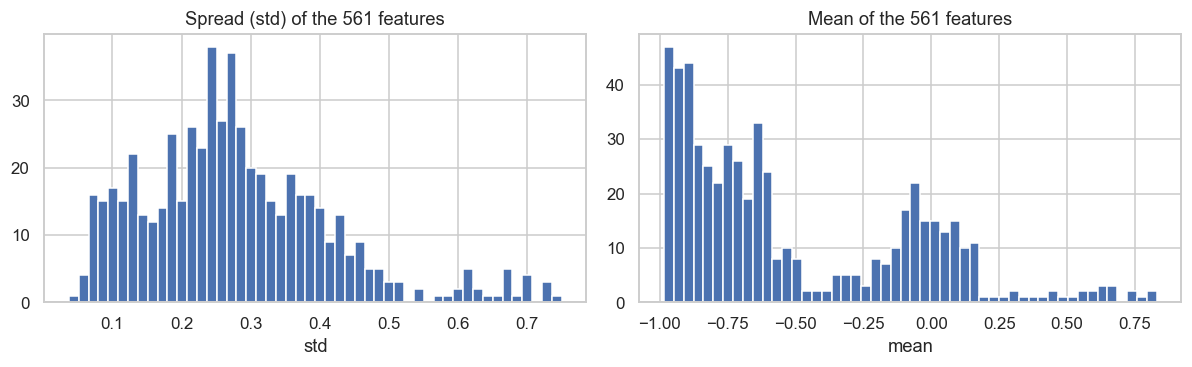

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
desc["std"].hist(bins=50, ax=ax[0]);  ax[0].set_title("Spread (std) of the 561 features"); ax[0].set_xlabel("std")
desc["mean"].hist(bins=50, ax=ax[1]); ax[1].set_title("Mean of the 561 features");        ax[1].set_xlabel("mean")
plt.tight_layout(); plt.show()

### 1.3 Missing values, duplicates, outliers

Features are bounded in [-1, 1], so extreme outliers are limited by design. We
still check missing values, duplicate rows, and a few boxplots.

Missing values : 0
Duplicate rows : 0


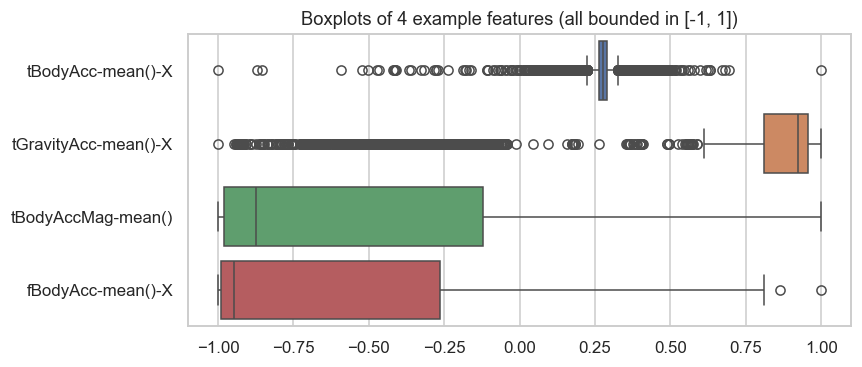

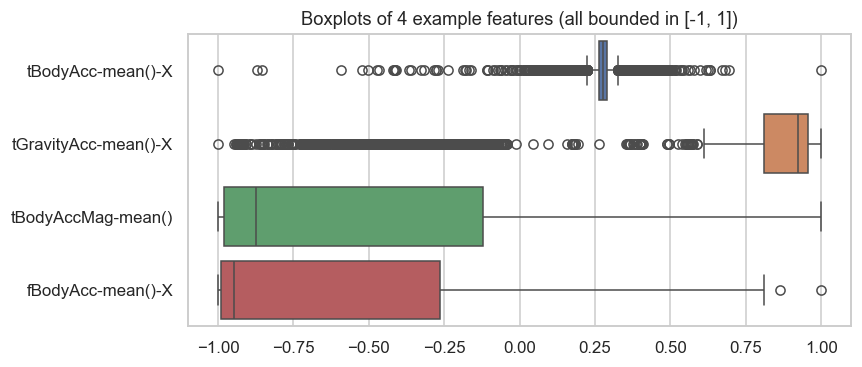

In [12]:
print("Missing values :", int(X.isna().sum().sum()))
print("Duplicate rows :", int(X.duplicated().sum()))

sample_feats = ["tBodyAcc-mean()-X", "tGravityAcc-mean()-X", "tBodyAccMag-mean()", "fBodyAcc-mean()-X"]
plt.figure(figsize=(8, 3.5))
sns.boxplot(data=X[sample_feats], orient="h")
plt.title("Boxplots of 4 example features (all bounded in [-1, 1])")
plt.tight_layout(); plt.show()

### 1.4 Distributions of a few features

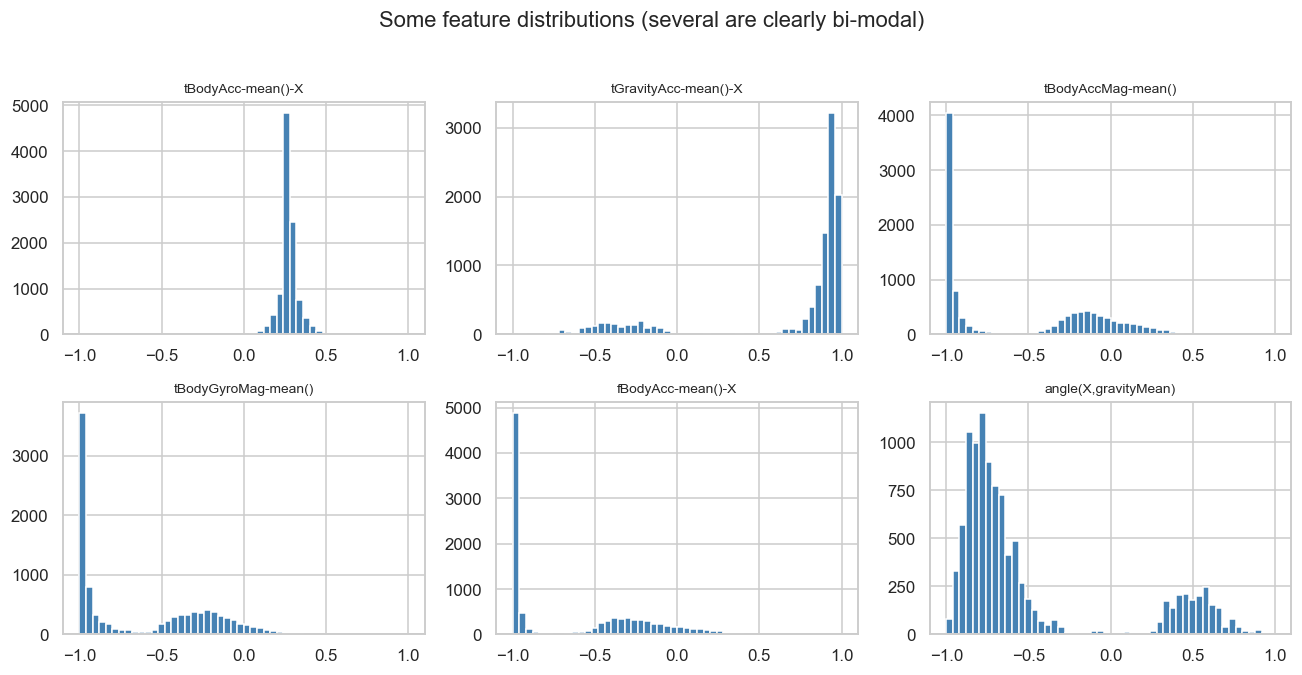

In [13]:
show_feats = ["tBodyAcc-mean()-X", "tGravityAcc-mean()-X", "tBodyAccMag-mean()",
              "tBodyGyroMag-mean()", "fBodyAcc-mean()-X", "angle(X,gravityMean)"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, f in zip(axes.ravel(), show_feats):
    ax.hist(X[f], bins=50, color="steelblue")
    ax.set_title(f, fontsize=9)
plt.suptitle("Some feature distributions (several are clearly bi-modal)", y=1.02)
plt.tight_layout(); plt.show()

### 1.5 Correlation matrix and redundancy

561x561 is too big to read, so we show a heatmap of the first 40 features, then
**measure** how redundant the 561 features are overall.

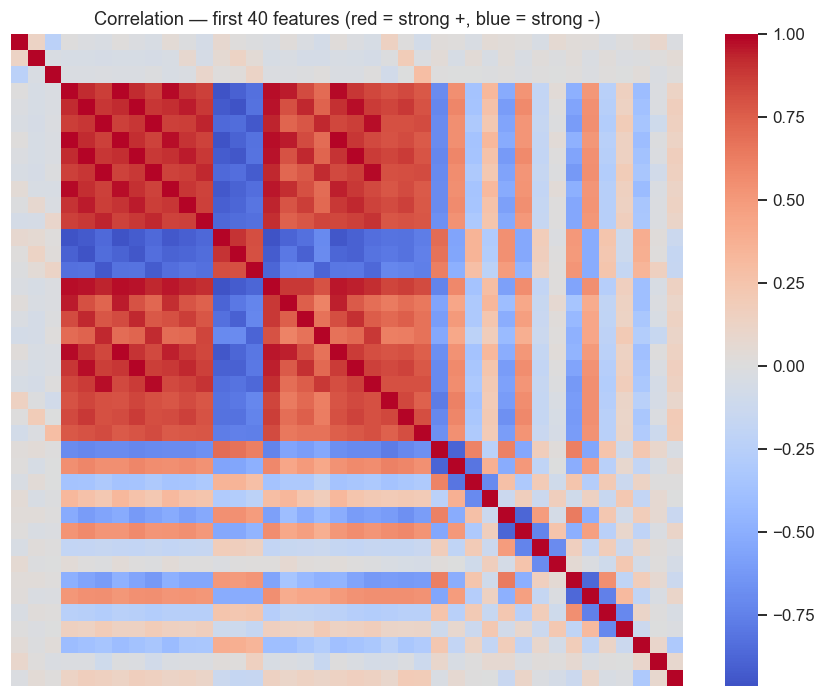

Pairs with |corr| > 0.90 : 8,093 of 157,080
Features with a near-twin |corr| > 0.90 : 429 of 561
Features with a near-twin |corr| > 0.95 : 392 of 561


In [14]:
corr = X.corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(X.iloc[:, :40].corr(), cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False)
plt.title("Correlation — first 40 features (red = strong +, blue = strong -)")
plt.tight_layout(); plt.show()

# how many feature PAIRS are near-duplicates?
upper = np.triu(np.ones(corr.shape, dtype=bool), k=1)
abs_pairs = corr.abs().where(upper)
n_pairs = int(upper.sum())
print(f"Pairs with |corr| > 0.90 : {int((abs_pairs > 0.90).sum().sum()):,} of {n_pairs:,}")

# how many individual FEATURES have at least one near-twin?
full = corr.abs().values.copy()
np.fill_diagonal(full, 0)
max_off = full.max(axis=1)
print(f"Features with a near-twin |corr| > 0.90 : {int((max_off > 0.90).sum())} of 561")
print(f"Features with a near-twin |corr| > 0.95 : {int((max_off > 0.95).sum())} of 561")

### 1.6 The finding that surprised us  ⭐

**561 features, but most of them repeat each other.** **429 of the 561 features
(76%)** have a near-twin — another feature with |corr| > 0.9 — and 392 have one
above 0.95. So the 561 numbers carry far less than 561 independent pieces of
information: mean / std / mad / energy of the same signal all move together.

Why it matters for the project: this is exactly **why PCA will shine here** — it
can compress hundreds of correlated columns into a few components with little
loss. We expected "561 features = a lot of information"; really it is a handful
of real directions repeated many times.

*(Second small surprise: the data is already pre-normalized to [-1, 1], unlike
most raw datasets where scales are wild.)*

### 1.7 Scaling — `StandardScaler`

Even though data is bounded in [-1, 1], the **variance differs** between
features. KMeans (distances) and PCA (variance directions) would let
high-variance features dominate. `StandardScaler` gives every feature mean 0 and
std 1, so all features get an equal say.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("After StandardScaler:")
print("  mean of all features (~0):", round(float(X_scaled.mean().mean()), 6))
print("  std  of all features (~1):", round(float(X_scaled.std().mean()), 6))
X_scaled.iloc[:3, :5]

After StandardScaler:
  mean of all features (~0): 0.0
  std  of all features (~1): 1.000049


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
0,0.210534,-0.068703,-0.452195,-0.883335,-0.945431
1,0.060208,0.035902,-0.275222,-0.890098,-0.929817
2,0.078460,-0.046427,-0.085548,-0.883565,-0.913598


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
0,0.210534,-0.068703,-0.452195,-0.883335,-0.945431
1,0.060208,0.035902,-0.275222,-0.890098,-0.929817
2,0.078460,-0.046427,-0.085548,-0.883565,-0.913598


**Step 1 done.** We now have:
- `X_scaled` — scaled feature matrix, ready for KMeans and PCA;
- one EDA finding to present (76% of features have a near-twin -> PCA will shine).

> Next: **Step 2 — KMeans** (choose `k` with the elbow method + silhouette).

---
# Step 2 — KMeans & choosing k

> The data has **no label to train on**, so we let KMeans find the structure.
> The only real question is **how many clusters `k`**. We do **not** guess it:
> we run KMeans for a range of `k` and read two curves — **inertia** (the elbow
> method) and the **silhouette** score — then pick `k` and justify it. We also
> distrust the first `k` a metric hands us and check the neighbours.

We cluster **`X_scaled` only**; `y_true` stays hidden until the final honesty
check.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)            # try k = 2 .. 10
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    # silhouette on the full 10k x 561 is O(n^2); a fixed 2000-row sample is enough
    sil = silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

scan = pd.DataFrame(rows).set_index("k")
scan["inertia_drop_%"] = (-scan["inertia"].pct_change() * 100).round(1)   # drop vs previous k
scan.round({"inertia": 0, "silhouette": 4})

,inertia,silhouette,inertia_drop_%
k,,,
2,3272857.0,0.3966,NaN
3,2921078.0,0.3137,10.7
4,2781602.0,0.1537,4.8
5,2654790.0,0.1340,4.6
6,2577180.0,0.1063,2.9
7,2519774.0,0.0767,2.2
8,2465379.0,0.0729,2.2
9,2415695.0,0.0717,2.0
10,2372408.0,0.0762,1.8


### 2.1 Read the two curves

- **Elbow (inertia):** inertia always falls as `k` grows; we look for the `k`
  where it *stops* falling fast — the bend ("elbow").
- **Silhouette:** higher is better (range −1…1); it rewards clusters that are
  tight inside and well separated from each other. We look for a peak.

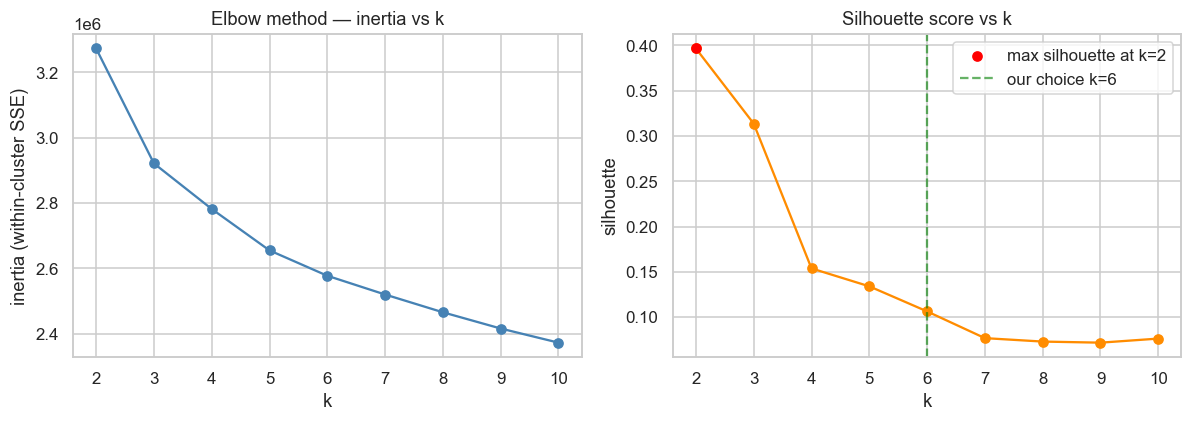

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(scan.index, scan["inertia"], "o-", color="steelblue")
ax[0].set_title("Elbow method — inertia vs k")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia (within-cluster SSE)")

ax[1].plot(scan.index, scan["silhouette"], "o-", color="darkorange")
best_k = int(scan["silhouette"].idxmax())
ax[1].scatter([best_k], [scan.loc[best_k, "silhouette"]], color="red", zorder=5,
              label=f"max silhouette at k={best_k}")
ax[1].axvline(6, color="green", ls="--", alpha=0.6, label="our choice k=6")
ax[1].set_title("Silhouette score vs k")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette"); ax[1].legend()

plt.tight_layout(); plt.show()

### 2.2 What the curves say (and the trap)

- **Silhouette is highest at k=2 (≈0.40)** and then falls steadily — there is no
  second peak.
- **Inertia** drops hard from k=2→3 (−10.7%), then the drops shrink to ~4–5%
  (k=4, 5) and to ≤3% from k=6 on. So the only sharp bend is early (k≈3); after
  that the curve just slowly flattens.

Taken literally, both metrics point at a **small k (2–3)**. That is exactly the
moment to **not trust the first `k`**: a silhouette peak at k=2 usually means the
data has one big, obvious gap. Let's open up that k=2 split before deciding.

In [18]:
# Why does silhouette love k=2? Inspect the two clusters WITHOUT using labels.
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_scaled)
look = pd.DataFrame({
    "size": pd.Series(km2.labels_).value_counts().sort_index(),
    # body-acceleration magnitude: ~ -1 when the phone is still, higher when moving
    "tBodyAccMag-mean()": X.groupby(km2.labels_)["tBodyAccMag-mean()"].mean().round(3),
})
look.index.name = "cluster"
look

,size,tBodyAccMag-mean()
cluster,,
0,5620,-0.951
1,4679,-0.064


### 2.3 The k=2 split is just "moving vs still"

One cluster (~5.6k rows) has `tBodyAccMag-mean()` ≈ **−0.95** (almost no body
acceleration → **static**: sitting / standing / laying); the other (~4.7k rows)
sits much higher at ≈ **−0.06** (**dynamic**: the three walking activities). So
the biggest gap in the data — the one silhouette rewards — is the coarse
**movement vs rest** split. Good to know, but too coarse for our goal of
recovering the **six** activities.

In [19]:
# Don't pick on a knife-edge: compare k around our target (5, 6, 7).
scan.loc[5:7].round({"inertia": 0, "silhouette": 4})

,inertia,silhouette,inertia_drop_%
k,,,
5,2654790.0,0.1340,4.6
6,2577180.0,0.1063,2.9
7,2519774.0,0.0767,2.2


### 2.4 Decision — we choose **k = 6**

Reasoning, using only the unsupervised signals (no labels yet):

1. **Elbow:** there is no single sharp knee after the trivial k=2 split. Inertia
   keeps paying off until the per-step drop falls below ~3% — that happens around
   **k=6**, after which the curve is essentially flat. So k≈6 is where extra
   clusters stop buying much.
2. **Silhouette:** its k=2 peak only reflects the one big movement / rest gap; it
   *under*-rewards larger k because several real activities physically overlap
   (e.g. sitting vs standing look almost the same to the sensors). A low
   silhouette at k=6 (~0.11) is expected, not a red flag — it does not prove k=2
   is the "true" structure, it just says the finer clusters touch each other.
3. **Neighbour check:** k=5, 6, 7 share almost the same inertia trend and a
   slowly-falling silhouette (0.134 → 0.106 → 0.077) — no neighbour is clearly
   better, so k=6 is a **stable** choice, not balanced on a fragile peak.
4. **Goal fit:** 6 matches the number of human activities we hope to recover.
   This is a hypothesis, not proof — the **honesty check in Step 5** (against the
   hidden `y_true`) is what will confirm or reject it.

In [21]:
# Final clustering for the rest of the project.
kmeans = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X_scaled)
clusters = pd.Series(kmeans.labels_, index=X.index, name="cluster")

summary = pd.DataFrame({
    "size": clusters.value_counts().sort_index(),
    "tBodyAccMag-mean()": X.groupby(clusters)["tBodyAccMag-mean()"].mean().round(3),
})
summary.index.name = "cluster"
print("Chosen k = 6 | silhouette =", round(scan.loc[6, "silhouette"], 3))
summary

Chosen k = 6 | silhouette = 0.106


,size,tBodyAccMag-mean()
cluster,,
0,2638,-0.981
1,307,0.231
2,1920,0.041
3,2449,-0.184
4,1338,-0.856
5,1647,-0.979


**Step 2 done.** We have:
- `scan` — inertia + silhouette for k = 2…10 (the evidence for the choice);
- `kmeans` — the fitted model, and `clusters` — the cluster id (0…5) per row.

We chose **k = 6**: the elbow flattens around there and it matches the six
activities we want to find, while staying honest that silhouette alone would
have stopped at the coarse movement / rest split.

> Next: **Step 3 — label the clusters** (give each cluster id a human-readable
> name) and only then compare against the hidden truth.

---
# Step 3 — build the prediction target (name the clusters)

> KMeans gave each row a number 0…5. **That number is our new label** — a target
> that did **not** exist in the raw data; we *constructed* it. Two jobs here:
> 1. add the cluster id as a column in the table;
> 2. give each cluster a **human name from its average features** (like
>    "still & upright"), not "cluster 0" — the name must say what makes the group
>    different from the others.
>
> We still **do not** touch `y_true`; naming uses feature profiles only. The
> truth check waits for Step 5.

In [22]:
df["cluster"] = clusters            # the constructed target, aligned by row index
print("New column 'cluster' added to the table. Sizes:")
print(df["cluster"].value_counts().sort_index().to_dict())
df[["subject", "split", "cluster"]].head()

New column 'cluster' added to the table. Sizes:
{0: 2638, 1: 307, 2: 1920, 3: 2449, 4: 1338, 5: 1647}


,subject,split,cluster
0,1,train,0
1,1,train,0
2,1,train,0
3,1,train,0
4,1,train,0


### 3.1 Profile each cluster by its average features

To name a cluster we look at **what its rows have in common**. We pick a handful
of physically meaningful features and take the **mean per cluster**:
- **movement level** — `tBodyAccMag-*`, `*JerkMag`, `tBodyGyroMag` (low ≈ still,
  high ≈ active);
- **orientation** — `tGravityAcc-mean()-X/Y/Z`, `angle(X,gravityMean)` (where
  gravity points tells us upright vs lying down).

In [23]:
profile_feats = [
    "tBodyAccMag-mean()", "tBodyAccMag-std()", "tBodyAccJerkMag-mean()",
    "tBodyGyroMag-mean()", "fBodyAccMag-mean()",          # movement level
    "tGravityAcc-mean()-X", "tGravityAcc-mean()-Y", "tGravityAcc-mean()-Z",
    "angle(X,gravityMean)",                                # orientation
]
raw_means = X.groupby(df["cluster"])[profile_feats].mean()
raw_means.insert(0, "size", df["cluster"].value_counts().sort_index())
print("Average feature values per cluster (raw, features live in -1..1):")
raw_means.round(3).T

Average feature values per cluster (raw, features live in -1..1):


cluster,0,1,2,3,4,5
size,2638.000,307.000,1920.000,2449.000,1338.000,1647.000
tBodyAccMag-mean(),-0.981,0.231,0.041,-0.184,-0.856,-0.979
tBodyAccMag-std(),-0.980,0.199,-0.043,-0.319,-0.817,-0.978
tBodyAccJerkMag-mean(),-0.986,0.171,-0.124,-0.406,-0.958,-0.987
tBodyGyroMag-mean(),-0.976,0.144,-0.141,-0.288,-0.842,-0.972
fBodyAccMag-mean(),-0.980,0.321,0.003,-0.319,-0.863,-0.981
tGravityAcc-mean()-X,0.894,0.902,0.916,0.909,0.600,-0.322
tGravityAcc-mean()-Y,-0.058,-0.207,-0.213,-0.218,0.069,0.672
tGravityAcc-mean()-Z,0.042,-0.138,-0.072,-0.080,0.173,0.597
"angle(X,gravityMean)",-0.728,-0.733,-0.742,-0.712,-0.439,0.478


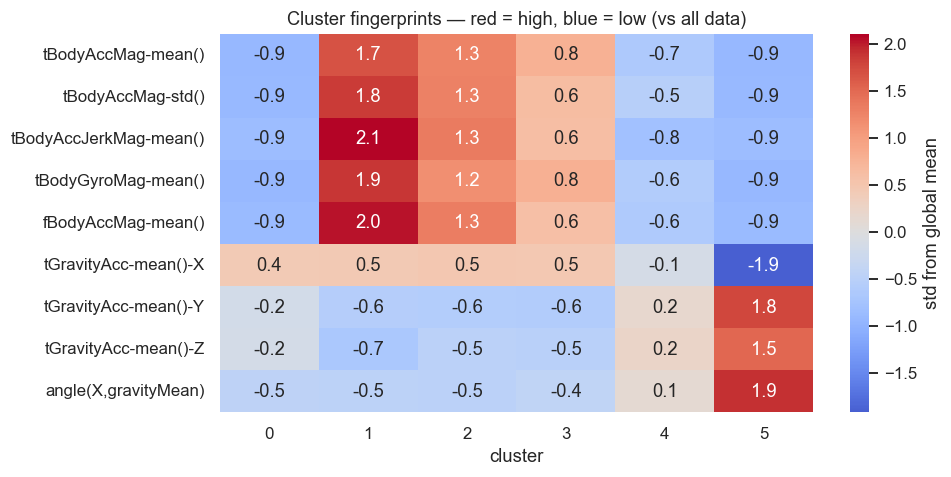

In [24]:
# z-score the cluster means so we can read "high / low vs the whole population"
z = (X.groupby(df["cluster"])[profile_feats].mean() - X[profile_feats].mean()) / X[profile_feats].std()

plt.figure(figsize=(9, 4.5))
sns.heatmap(z.T, cmap="coolwarm", center=0, annot=True, fmt=".1f",
            cbar_kws={"label": "std from global mean"})
plt.title("Cluster fingerprints — red = high, blue = low (vs all data)")
plt.xlabel("cluster"); plt.ylabel("")
plt.tight_layout(); plt.show()

### 3.2 Read the fingerprints

Two axes separate everything:

- **Movement** (top rows). Clusters **1, 2, 3** are red → **active**; clusters
  **0, 4, 5** are blue → **still**. Inside the active group the intensity rises
  **3 → 2 → 1** (cluster 1 has the highest jerk / energy of all).
- **Orientation** (gravity rows). Cluster **5** flips: gravity leaves the X axis
  (blue, −1.9 std) and moves to Y/Z (red) → the body is **horizontal (lying
  down)**. Everyone else is **upright** (gravity on X). Among the still-upright
  pair, **0** is the most frozen and most vertical; **4** is slightly tilted with
  a touch more motion.

### 3.3 Human names

| cluster | size | what stands out (from features) | name |
|--------:|-----:|----|----|
| 0 | 2638 | stillest of all, firmly upright (gravity on X) | **Still — upright, at rest** |
| 4 | 1338 | still & upright but slightly tilted, faint motion | **Still — upright, tilted** |
| 5 | 1647 | still but **horizontal** — gravity on Y/Z, not X | **Still — lying down** |
| 3 | 2449 | moderate body acceleration, upright, steady | **Active — light & steady** |
| 2 | 1920 | high acceleration & rotation, upright | **Active — strong** |
| 1 |  307 | **highest** jerk / high-frequency energy of all | **Active — vigorous (high impact)** |

Each name says how the group differs: the three *Still* clusters share low motion
but split by **posture** (upright at rest / upright tilted / lying); the three
*Active* clusters share high motion but split by **intensity** (light / strong /
vigorous).

*Honest caveats:* (1) cluster **1** is small (307) — k=6 carved out only the
*purest* vigorous windows, so clusters are **not** a perfect 1-to-1 with real
activities; (2) the two upright-still clusters (**0** vs **4**) are the close,
overlapping pair the silhouette warned us about. Whether these names match the
true activities is exactly what **Step 5** will test — we have **not** looked at
`y_true`.

In [26]:
# names come from the feature fingerprints above (NOT from y_true)
cluster_names = {
    0: "Still - upright, at rest",
    1: "Active - vigorous (high impact)",
    2: "Active - strong",
    3: "Active - light & steady",
    4: "Still - upright, tilted",
    5: "Still - lying down",
}
df["cluster_name"] = df["cluster"].map(cluster_names)

print("Constructed target ready. Rows per named cluster:")
print(df["cluster_name"].value_counts())
df[["subject", "split", "cluster", "cluster_name"]].head()

Constructed target ready. Rows per named cluster:
cluster_name
Still - upright, at rest           2638
Active - light & steady            2449
Active - strong                    1920
Still - lying down                 1647
Still - upright, tilted            1338
Active - vigorous (high impact)     307
Name: count, dtype: int64


,subject,split,cluster,cluster_name
0,1,train,0,"Still - upright, at rest"
1,1,train,0,"Still - upright, at rest"
2,1,train,0,"Still - upright, at rest"
3,1,train,0,"Still - upright, at rest"
4,1,train,0,"Still - upright, at rest"


**Step 3 done.** The table now carries a **constructed target** we built from the
data itself:
- `df["cluster"]` — the cluster id (0…5);
- `df["cluster_name"]` — a human name that explains the group (posture for the
  still ones, intensity for the active ones).

`y_true` is still untouched. Next: **Step 4 — PCA** (compress the 561 correlated
features), then **Step 5 — classification** + the honesty check against the real
activities.

---
# Step 4 — PCA: a 2-D sanity check

> 561 features can't be seen by eye. We compress them to **2 principal
> components** and plot every window on a plane, **coloured by the Step-3 label**.
> Then we ask: do the clusters separate, or overlap? We also report **how much
> variance** the 2 components keep — if it is low, the flat picture is partly an
> illusion, which is itself a finding.

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_scaled)                 # 10299 x 2
ev = pca.explained_variance_ratio_ * 100
print(f"PC1 keeps {ev[0]:.1f}%, PC2 keeps {ev[1]:.1f}%  ->  2-D keeps {ev.sum():.1f}% of all variance")

# how redundant is the data really? (ties back to the Step-1 finding)
cum = np.cumsum(PCA(random_state=42).fit(X_scaled).explained_variance_ratio_)
for thr in (0.90, 0.95):
    print(f"  components needed for {int(thr*100)}% variance: {int(np.argmax(cum >= thr) + 1)} of 561")

PC1 keeps 50.7%, PC2 keeps 6.2%  ->  2-D keeps 57.0% of all variance
  components needed for 90% variance: 65 of 561
  components needed for 95% variance: 104 of 561


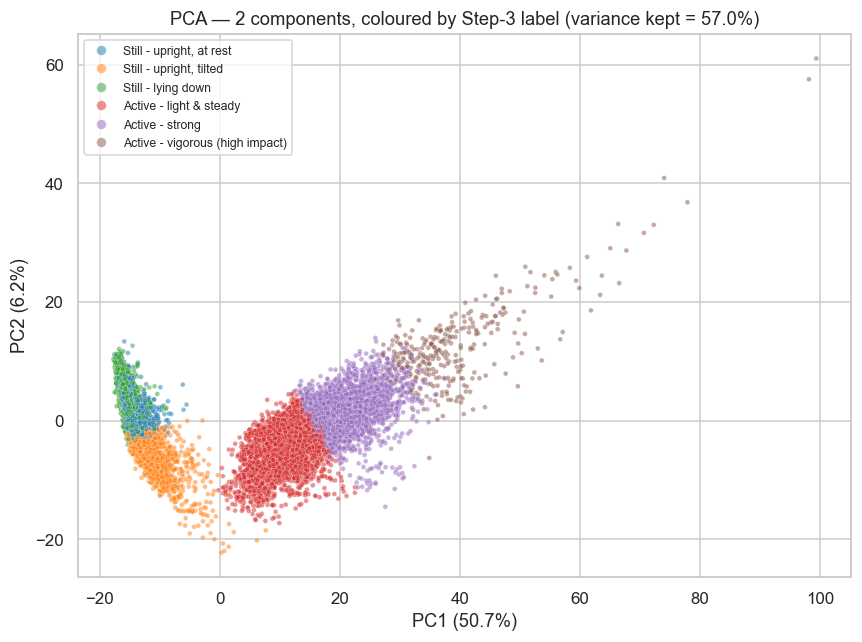

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pc[:, 0], y=pc[:, 1], hue=df["cluster_name"],
                s=10, alpha=0.5, palette="tab10")
plt.title(f"PCA — 2 components, coloured by Step-3 label (variance kept = {ev.sum():.1f}%)")
plt.xlabel(f"PC1 ({ev[0]:.1f}%)"); plt.ylabel(f"PC2 ({ev[1]:.1f}%)")
plt.legend(markerscale=2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

### 4.1 What the picture shows

- **PC1 alone keeps 50.7%** and it *is* the movement axis: every **Still** cluster
  sits on the left, every **Active** cluster on the right, with a clear gap
  between them. The big **rest vs movement** split (the same one silhouette found
  at k=2) is real and obvious.
- **Inside each half it gets blurry.** The three still clusters (at-rest / tilted
  / lying) pile on top of each other on the left; the three active clusters form a
  smooth **intensity gradient** (light → strong → vigorous) with no clean borders.

### 4.2 But the 2-D picture is only **57% of the truth**

Two components keep **57.0%** of the variance — so **43% is not on the screen**.
The overlaps we see are therefore partly an **artifact of flattening**: clusters
that look merged here may still be separable in the full 561-D space. (Step 5
tests exactly that — a classifier hits ~98%, so they *are* more separable than
this plot suggests.) Lesson: **trust the big split, distrust the apparent
overlaps** until a model in full dimensions checks them.

*Bonus (ties to Step 1):* it takes **65 components for 90%** and **104 for 95%**
of the variance — heavy redundancy, exactly as the "76% of features have a
near-twin" finding predicted. PCA really does shine here.

---
# Step 5 — Classification: is the label real?

> A clustering can invent groups that are just noise. The test: can a classifier
> **predict the Step-3 cluster label from the raw features**? We split into
> train / test, train **Logistic Regression** and **KNN**, and read
> **accuracy / precision / recall / F1**.
> - High scores → the groups have **learnable boundaries** → they are real and
>   separable.
> - Low scores → we admit the clustering produced **fuzzy** groups.
>
> Then the **honesty check**: only now do we un-hide `y_true` (the real activity)
> and compare it with our clusters in a contingency table — where did our
> unsupervised groups match the real activities, and where did they go wrong?

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

y = df["cluster"]                                        # our constructed target
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)   # stratify keeps tiny cluster 1 in both

scaler5 = StandardScaler().fit(X_tr)                     # fit on train only -> no leakage
X_tr_s, X_te_s = scaler5.transform(X_tr), scaler5.transform(X_te)

models = {"LogReg": LogisticRegression(max_iter=2000),
          "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)}
scores, preds = [], {}
for name, clf in models.items():
    clf.fit(X_tr_s, y_tr)
    p = clf.predict(X_te_s); preds[name] = p
    acc = accuracy_score(y_te, p)
    pr, rc, f1, _ = precision_recall_fscore_support(y_te, p, average="macro", zero_division=0)
    scores.append({"model": name, "accuracy": acc, "precision": pr, "recall": rc, "f1": f1})

print(f"train: {X_tr.shape[0]} rows | test: {X_te.shape[0]} rows | classes: {y.nunique()}")
pd.DataFrame(scores).set_index("model").round(4)

train: 7724 rows | test: 2575 rows | classes: 6


,accuracy,precision,recall,f1
model,,,,
LogReg,0.9790,0.9735,0.9637,0.9683
KNN (k=5),0.9262,0.9415,0.8821,0.9058


Per-class report — Logistic Regression (labels = cluster ids 0..5):
              precision    recall  f1-score   support

           0      0.980     0.986     0.983       660
           1      0.944     0.870     0.905        77
           2      0.957     0.981     0.969       480
           3      0.992     0.980     0.986       612
           4      0.968     0.991     0.979       334
           5      1.000     0.973     0.986       412

    accuracy                          0.979      2575
   macro avg      0.973     0.964     0.968      2575
weighted avg      0.979     0.979     0.979      2575



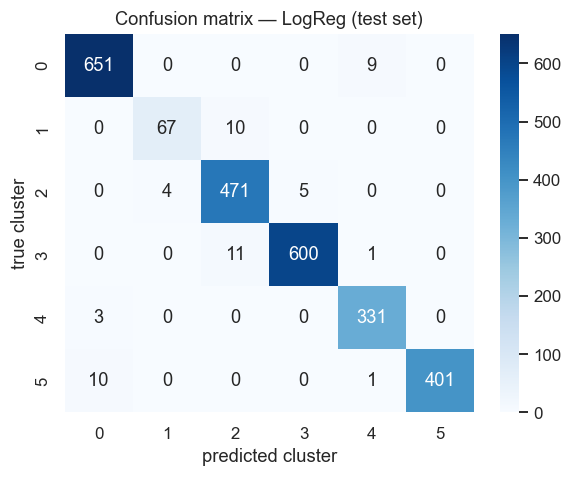

In [30]:
print("Per-class report — Logistic Regression (labels = cluster ids 0..5):")
print(classification_report(y_te, preds["LogReg"], zero_division=0, digits=3))

cm = confusion_matrix(y_te, preds["LogReg"])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(6), yticklabels=range(6))
plt.title("Confusion matrix — LogReg (test set)")
plt.xlabel("predicted cluster"); plt.ylabel("true cluster")
plt.tight_layout(); plt.show()

### 5.1 The label is **not random**

Logistic Regression reaches **accuracy 0.979** and **macro-F1 0.968** (KNN: 0.926
/ 0.906). Almost every window lands in the right cluster; the only soft spot is
the tiny **cluster 1** (*Active — vigorous*, recall ≈ 0.87), which blurs into the
neighbouring active clusters. So the six groups have **clear, learnable
boundaries** — they are real, separable structure, **not** noise.

One honest note: this high score is partly **by construction** — the label was
made by KMeans on these same features, so the classifier mostly re-traces those
boundaries. It proves the clusters are **internally consistent and separable**;
it does **not** prove they equal the real activities. That is the next test.

### 5.2 Honesty check — un-hide the real activity

Now — and **only** now — we compare our **constructed** clusters with the **true**
activity `y_true` that stayed hidden the whole project. (Same idea as the Seeds
task: predict your own kmeans label first, *then* pull the real class and compare
with a contingency table.)

Counts — each cluster vs real activity:
activity                         LAYING  SITTING  STANDING  WALKING  \
cluster_name                                                          
Active - light & steady               5        1         0      897   
Active - strong                       0        0         0      741   
Active - vigorous (high impact)       0        0         0       84   
Still - lying down                 1556       91         0        0   
Still - upright, at rest             54     1238      1346        0   
Still - upright, tilted             329      447       560        0   

activity                         WALKING_DOWNSTAIRS  WALKING_UPSTAIRS  
cluster_name                                                           
Active - light & steady                         310              1236  
Active - strong                                 882               297  
Active - vigorous (high impact)                 214                 9  
Still - lying down             

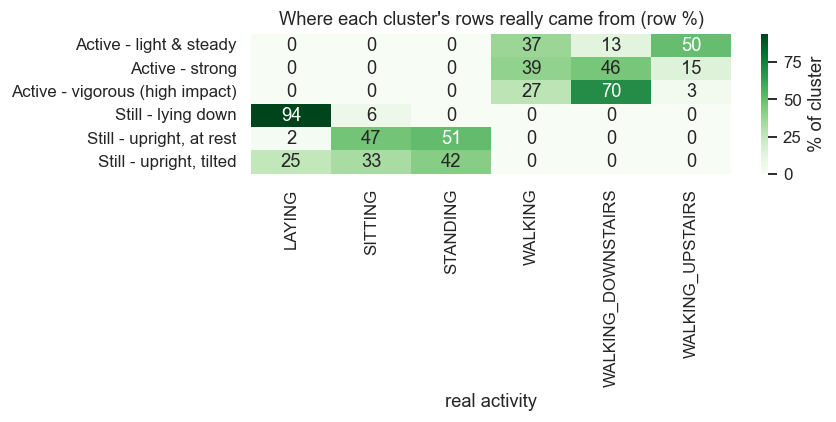

Adjusted Rand Index (clusters vs real activity): 0.42
Majority-vote purity: 0.563

Each cluster's majority real activity:
cluster_name
Active - light & steady              WALKING_UPSTAIRS
Active - strong                    WALKING_DOWNSTAIRS
Active - vigorous (high impact)    WALKING_DOWNSTAIRS
Still - lying down                             LAYING
Still - upright, at rest                     STANDING
Still - upright, tilted                      STANDING
dtype: object


In [31]:
from sklearn.metrics import adjusted_rand_score

ct = pd.crosstab(df["cluster_name"], y_true)
print("Counts — each cluster vs real activity:")
print(ct)

row_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(0).astype(int)
plt.figure(figsize=(8, 4))
sns.heatmap(row_pct, annot=True, fmt="d", cmap="Greens", cbar_kws={"label": "% of cluster"})
plt.title("Where each cluster's rows really came from (row %)")
plt.xlabel("real activity"); plt.ylabel("")
plt.tight_layout(); plt.show()

maj = ct.idxmax(axis=1)
purity = sum(ct.loc[c, maj[c]] for c in ct.index) / ct.values.sum()
print("Adjusted Rand Index (clusters vs real activity):", round(adjusted_rand_score(y_true, df["cluster"]), 3))
print("Majority-vote purity:", round(purity, 3))
print("\nEach cluster's majority real activity:")
print(maj)

### 5.3 Did the clusters match the real activities?

**Partly.** ARI = **0.42**, majority-vote purity = **0.56** — real overlap, but
far from a perfect match. KMeans found a structure that is *valid but different*
from the official 6 labels: it organised windows by **movement intensity +
posture**, not by activity name.

**Where it matched (well):**
- **Lying down → LAYING (94%).** The orientation signal (gravity off the X axis)
  made this the cleanest cluster — a genuine, correct discovery.
- **The big move / rest split is essentially perfect:** no walking window fell
  into a still cluster, and no still window fell into an active one.

**Where it went wrong:**
- **Sitting vs standing were not separated.** *Still — at rest* is ~50/50
  STANDING/SITTING, and *Still — tilted* mixes STANDING + SITTING + some LAYING.
  These postures look almost identical to the sensors, so KMeans merged them —
  exactly the overlap the low silhouette and the PCA blob warned about.
- **The 3 walking types split by effort, not identity.** Flat WALKING is smeared
  across all three active clusters; *Active — vigorous* is ~70% WALKING_DOWNSTAIRS,
  *Active — strong* leans DOWNSTAIRS, *Active — light* leans UPSTAIRS. KMeans
  sorted walking by how intense it is, which only partly lines up with up/down/flat.

**Bottom line.** The label is real and separable (5.1) and it captures true
physical structure (rest/move, lying down). But it is **not** the activity label:
unsupervised KMeans recovered *intensity and posture*, and could not split the
near-identical sitting/standing or the three walking styles. An honest — and very
typical — result for clustering high-dimensional sensor data.